In [4]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("C:/Users/HLOGIZNBUCKS/Downloads/Data-Analytics-Training/Brazilian_E-commerce/data/cleaned_data.csv")

In [5]:
# Total Revenue
df['revenue'].sum()

np.float64(15419143.41)

In [7]:
# Total Profit
df['profit'].sum()

np.float64(11022646.81)

In [6]:
# Profit Margin (overall)
df['profit'].sum() / df['revenue'].sum()

np.float64(0.7148676497068782)

In [9]:
# Loss Order
df['loss_order'] = df['profit'] < 0
df['loss_order'].mean() * 100

np.float64(3.6371556136338885)

In [ ]:
Total Revenue -> 15419143.41
Total Profit -> 11022646.81
Profit Margin -> 0.7148676497068782
Loss Order -> 3.6371556136338885

In [10]:
df['order_month'] = pd.to_datetime(df['order_month'].astype(str))

monthly = df.groupby('order_month').agg({
    'revenue':'sum',
    'profit':'sum'
})

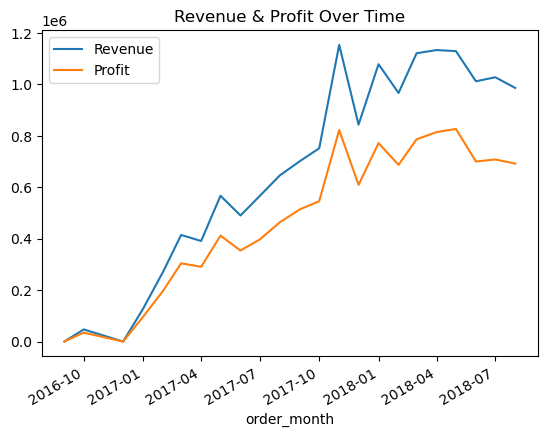

In [11]:
plt.figure()
monthly['revenue'].plot(label='Revenue')
monthly['profit'].plot(label='Profit')
plt.legend()
plt.title("Revenue & Profit Over Time")
plt.show()

In [ ]:
Is Revenue growing? Yes, from 2016 to 2018 but after that it hasnt broken the 2018 high and its
playing around the levels between 0.8 and 1.2
Is Profit stable? Yes, but after 2018 profit stopped growing and started playing around 0.6 and 0.8

In [12]:
category = df.groupby('product_category_name')['revenue'].sum().sort_values(ascending=False)

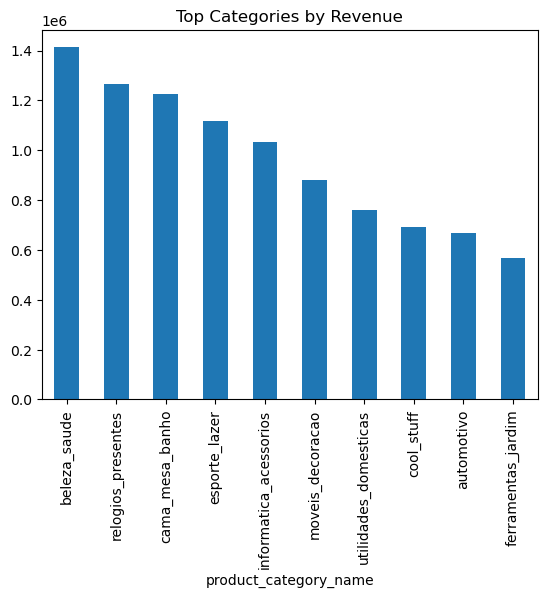

In [13]:
category.head(10).plot(kind='bar')
plt.title("Top Categories by Revenue")
plt.show()

In [ ]:
Beleza_saude is the category that is dominating

In [15]:
# Loss by category
loss_cat = df.groupby('product_category_name')['loss_order'].mean().sort_values(ascending=False)

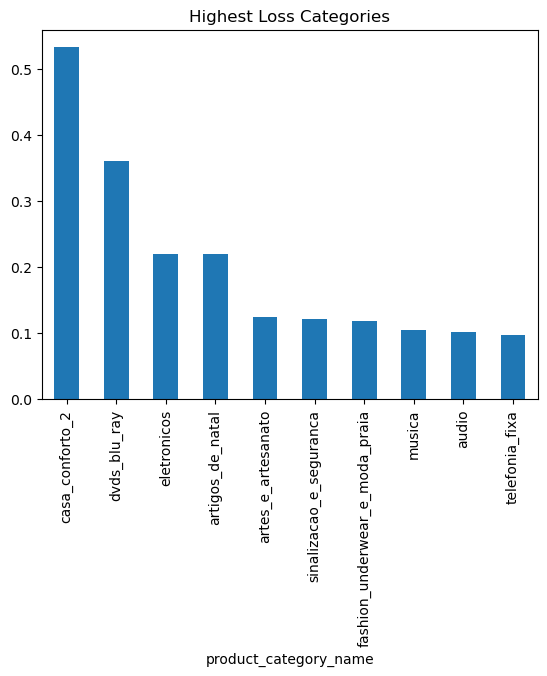

In [16]:
loss_cat.head(10).plot(kind='bar')
plt.title("Highest Loss Categories")
plt.show()

In [ ]:
casa_conorto_2 is a category that is unprofitable

In [17]:
# Average delivery time
df['delivery_time'].mean()

np.float64(12.007722603361284)

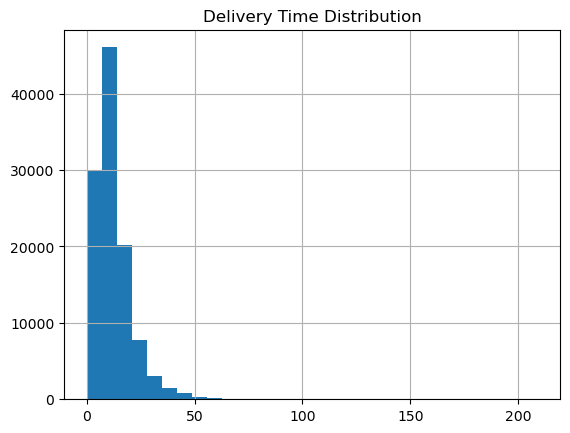

In [18]:
df['delivery_time'].hist(bins=30)
plt.title("Delivery Time Distribution")
plt.show()

In [ ]:
Is delivery slow? 
Are there outliers? 

In [19]:
# Top customers
top_customers = df.groupby('customer_id')['revenue'].sum().sort_values(ascending=False).head(10)
print(top_customers)

customer_id
1617b1357756262bfa56ab541c47bc16    13664.08
ec5b2ba62e574342386871631fafd3fc     7274.88
c6e2731c5b391845f6800c97401a43a9     6929.31
f48d464a0baaea338cb25f816991ab1f     6922.21
3fd6777bbce08a352fddd04e4a7cc8f6     6726.66
05455dfa7cd02f13d132aa7a6a9729c6     6081.54
df55c14d1476a9a3467f131269c2477f     4950.34
24bbf5fd2f2e1b359ee7de94defc4a15     4764.34
3d979689f636322c62418b6346b1c6d2     4681.78
1afc82cd60e303ef09b4ef9837c9505c     4513.32
Name: revenue, dtype: float64


In [ ]:
Is revenue concentrated?

In [20]:
monthly.to_csv("C:/Users/HLOGIZNBUCKS/Downloads/Data-Analytics-Training/Brazilian_E-commerce/data/monthly_summary.csv")
category.to_csv("C:/Users/HLOGIZNBUCKS/Downloads/Data-Analytics-Training/Brazilian_E-commerce/data/category_summary.csv")